In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", desc = ["FHFFF", "FHGFF", "HFFHF", "FSFFF", "FFHHF"], is_slippery = True)

n_states = env.observation_space.n
n_actions = env.action_space.n

In [10]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995

In [11]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------


Q = np.zeros((n_states, n_actions))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """
    if np.random.rand() < epsilon:
        # Explore
        return env.action_space.sample()
    else:
        # Exploit
        return np.argmax(Q[state])

In [16]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):

    state, info = env.reset()

    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        next_state, reward, terminated, truncated, info = env.step(action)

        next_action = epsilon_greedy_action(next_state, epsilon)

        Q[state, action] += alpha * (
            reward + gamma * Q[next_state, next_action] - Q[state, action]
        )

        state = next_state
        action = next_action

        total_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)


In [13]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(5, 5), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(5, 5)

    print("\nLearned Policy:")
    print(policy_grid)


In [14]:
# -------------------------------------------------
# Output
# -------------------------------------------------

state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)



Final Q-table:
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.564 0.1   0.053 0.038]
 [0.567 0.158 0.17  0.172]
 [0.1   0.126 0.158 0.414]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.377 0.259 0.046 0.767]
 [0.471 0.141 0.26  0.133]
 [0.    0.    0.    0.   ]
 [0.037 0.2   0.141 0.043]
 [0.364 0.132 0.282 0.198]
 [0.    0.    0.    0.   ]
 [0.215 0.118 0.302 0.171]
 [0.128 0.19  0.152 0.151]
 [0.192 0.195 0.202 0.193]
 [0.138 0.128 0.082 0.246]
 [0.064 0.146 0.057 0.085]
 [0.109 0.141 0.184 0.214]
 [0.173 0.168 0.188 0.171]
 [0.187 0.134 0.153 0.138]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.06  0.009 0.003 0.003]]

Estimated State-Value Function:
[[0.    0.    0.564 0.567 0.414]
 [0.    0.    0.    0.767 0.471]
 [0.    0.2   0.364 0.    0.302]
 [0.19  0.202 0.246 0.146 0.214]
 [0.188 0.187 0.    0.    0.06 ]]

Learned Policy:
[['L' 'L' 'L' 'L' 'U']
 ['L' 'L' 'L' 'U' 'L']
 ['L' 'D' 'L' 'L' 'R']
 ['D' 'R' 'U' 'D' 'U']


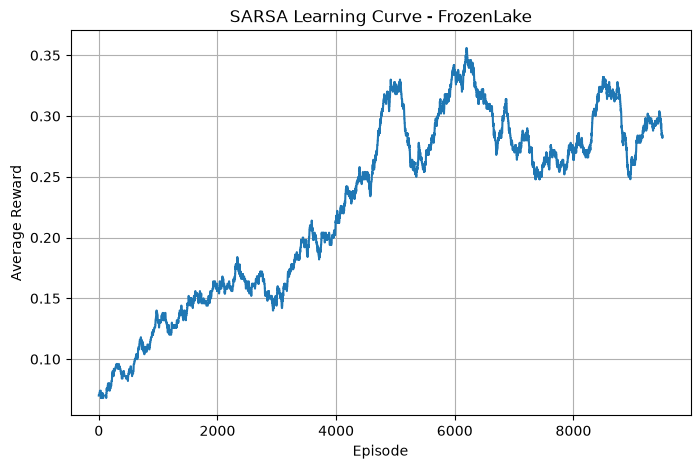

In [15]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()